# Load CSV Data to InterSystems IRIS with Python

Comma Separated Value (CSV) files is one of the most common, portable data types available. However, they are limited in scale and are not easily interlinked, hence the need for relational databases. 

There are many ways to load CSV files into InterSystems IRIS, but this tutorial will show how one can use the InterSystems IRIS Python DB-API driver to create a SQL table for the CSV file and then load in the data row by row. 

If you want to skip the tutorial and just use a robust and reusable class, [skip to the reusable class](#Reusable-Class) step at the end

## Prerequisites

This tutorial assumes you already have an instance of InterSystems IRIS running, according to the template included in this repository but it will work on any other InterSystems IRIS Instance as long as you have the following details: (template credentials shown in italics)

- Server (*localhost*)
- Port (*32782*) **Note this is the superserver port (default=1972), not the web-server port** 
- Namespace (*FHIRSERVER*)
- Username (*SuperUser*)
- Password (*SYS*)

You will also need Python installed on your computer, and the `intersystems-irispython` package installed.

In [1]:
pip install intersystems-irispython

   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------- ----------------- 2.1/3.7 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 11.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Creating a SQL connection to InterSystem IRIS

After installing the `intersystems-irispython` package, its easy to create a SQL connection to our InterSystems IRIS instance using the following syntax (note, there are several variations to this syntax that work). 


In [1]:
import iris

connection_args = {
	'hostname':'localhost', 
	'port': 32782,
	'namespace':'FHIRSERVER', 
	'username':'SuperUser', 
	'password':'SYS'
}

conn = iris.connect(**connection_args)
cursor = conn.cursor() 

status = cursor.execute("SELECT 'Hello From IRIS'")
output = cursor.fetchone()

print(output[0])

conn.close() 

Hello From IRIS


Its worth remembering to close connections, because InterSystems IRIS can have a limited number of active connections (particular with the Community Edition), so leaving connections open can lead to connections being blocked (License errors).

## Creating a table 

To create a SQL table, the data types for each column needs to be predefined in the `Create` statement. For simple tables this can be easily written manually, lets see a simple example: 

Table name: **Sample.Table**  (Note, Sample is a Package, Person is the table name in the package). 


|FirstName| LastName |Age|
|-|-|-|
|Peter|Parker|18|

This is created with the following SQL Data Definition Language (DDL):

```sql
CREATE TABLE Sample.Person (
                            FirstName VARCHAR(30),
                            LastName VARCHAR(30),
                            Age INTEGER
                            )
```

Each column is defined with its datatype `VARCHAR` is a String, with the "30" being the maximum length in characters. For arbitrarily long text, use `LONGVARCHAR`. For more information on SQL Datatypes, see [Data Types (SQL)](https://docs.intersystems.com/irislatest/csp/docbook/Doc.View.cls?KEY=RSQL_datatype#RSQL_datatype_work_with_specific_data_types)

Let's see this in Python: 

In [2]:
conn = iris.connect(**connection_args)
cursor = conn.cursor() 

create_table_statement = """ CREATE TABLE Sample.Person (
                            FirstName VARCHAR(30),
                            LastName VARCHAR(30),
                            Age INTEGER)"""



status = cursor.execute(create_table_statement)

The table should be created. You can check with the SQL Explorer from the management portal [here](http://localhost:32783/csp/sys/exp/%25CSP.UI.Portal.SQL.Home.zen?$NAMESPACE=FHIRSERVER) by executing the following query: 

```sql
SELECT 
FirstName, LastName, Age
FROM Sample.Person
```

## Inserting data

To insert data into the table, we use an `INSERT` query. The best way to do this, particularly if you have multiple values is by defining a query with placeholder `?`s, then running `cursor.execute` with the insert parameters as follows:

In [3]:
insert_statement = "INSERT INTO Sample.Person (FirstName, LastName, Age) VALUES (?, ?, ?) "

cursor.execute(insert_statement, ["Peter", "Parker", 18]) 

1

and if we have many rows of data: 

In [4]:
rows = [
    ["Bruce", "Wayne", 50],
    ["Natasha", "Romanoff", 30],
    ["Clark", "Kent", 35],
    ["Diana", "Prince", 32],
    ["Peter", "Parker", 25],
]

cursor.executemany(insert_statement, rows) 


(1, 1, 1, 1, 1)

We could get these values from a CSV File using `pandas`, a popular data analysis library. Note, this could also be done with the built in `csv` module, but `pandas` is widely used and better for inferring data types as you'll see in the next step. 

In [19]:
pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.7 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.7 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.7 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 13.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------------- -------------------------- 4.2/12.6 MB 21.0 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.6 MB 22.0 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 13.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd 

df = pd.read_csv("data/csv/superheros.csv")
df.head()

,first_name,last_name,age
0,Tony,Stark,45
1,Steve,Rogers,39
2,Carol,Danvers,34
3,Matt,Murdock,31
4,Barry,Allen,28


In [6]:
values_list = df.values.tolist()
cursor.executemany(insert_statement, values_list) 

conn.close()

## Inferring data types 

Ensuring the correct datatype is used for each column is important for performance and therefore, for important use cases, its best to carefully consider the DDL. However for small tables, simple files, and projects when query performance is not maximally important, you may wish to automate the table creation and filling from a CSV table. 

There is an example CSV File in `./data/csv/healthcare_dataset.csv`, the code below will show how this can automatically be converted into a SQL table in InterSystems IRIS.

The following script maps some common data-types to SQL. It isn't a perfect conversion as it only accounts for numbers and booleans, with anything else becoming Strings. 

It also misses some features of the dataset. For example, in the dataset we have a `results` column which can be one of "Normal", "Abnormal" or "Inconclusive", in the DDL we could limit this column to these 3 values which would validate and reject rows with any other value, but this type of specification is harder to do with simple automatic conversion. 

But, for simple or quick use cases, it works. 

In [ ]:
table_name ="Sample.HealthCareData"
csv_path = "./data/csv/healthcare_dataset.csv"


df = pd.read_csv(csv_path) 

# Mapping of Python datatypes to IRIS-SQL datatypes 
type_map = {
     "int64": "BIGINT",
     "float64": "DOUBLE",
     "bool": "BIT",
     "datetime64[ns]": "TIMESTAMP",
      "object": "VARCHAR(32000)"
        }



columns = []
for col, dtype in df.dtypes.items():


    # Get the IRIS SQL Datatype or default to column
    iris_type = type_map.get(str(dtype), "VARCHAR(32000)")

    col = col.replace(" ","") # Basic Santization, see below for more comprehensive example
    
    # Append columns list
    columns.append(f"{col} {iris_type}")


ddl = f"CREATE TABLE {table_name} ({', '.join(columns)})"

Now we have the DDL, we can create the table: 

In [ ]:
conn = iris.connect(**connection_args)
cursor = conn.cursor()

cursor.execute(ddl)

Then add the data: 

In [ ]:
raw_columns = [x.split(" ")[0] for x in columns] # Just the column names, not datatypes

placeholders = " ,".join(["?" for _ in raw_columns]) # Question mark for each column (comma separated)

insert_query = f"INSERT INTO {table_name} ({" , ".join(raw_columns)}) VALUES ({placeholders})"

In [54]:
values = df.values.tolist()
cursor.executemany(insert_query, values)

conn.close()

And with that, the full datatable should have been added. You can check from the [SQL Explorer](http://localhost:32783/csp/sys/exp/%25CSP.UI.Portal.SQL.Home.zen?$NAMESPACE=FHIRSERVER)

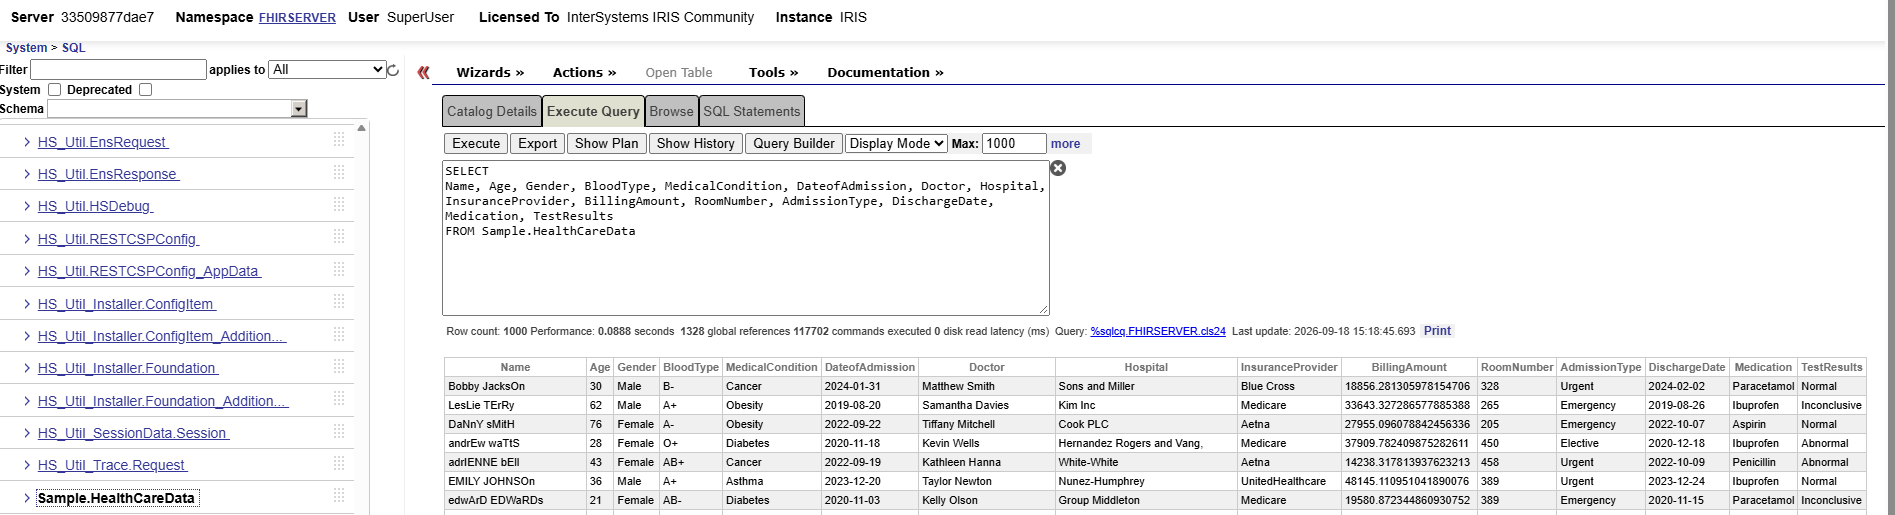



## Reusable Class

The tutorial above shows the logic behind adding a CSV file as an IRIS table. The class below shows a reasonably robust implementation of this, including sanitizing the inputs (including column names, table names and values). Feel free to take it for your own use case. 


In [ ]:
import re
import unicodedata

import iris
import pandas as pd
from pandas.api.types import (
    is_bool_dtype,
    is_datetime64_any_dtype,
    is_float_dtype,
    is_integer_dtype,
)

SQL_RESERVED_WORDS = {
    '%AFTERHAVING', '%ALLINDEX', '%ALPHAUP', '%ALTER', '%BEGTRANS', '%CHECKPRIV',
    '%CLASSNAME', '%CLASSPARAMETER', '%DBUGFULL', '%DELDATA', '%DESCRIPTION',
    '%EXACT', '%EXTERNAL', '%FILE', '%FIRSTTABLE', '%FLATTEN', '%FOREACH', '%FULL',
    '%ID', '%IDADDED', '%IGNOREINDEX', '%IGNOREINDICES', '%INLIST', '%INORDER',
    '%INTERNAL', '%INTEXT', '%INTRANS', '%INTRANSACTION', '%KEY', '%MATCHES',
    '%MCODE', '%MERGE', '%MINUS', '%MVR', '%NOCHECK', '%NODELDATA', '%NOFLATTEN',
    '%NOFPLAN', '%NOINDEX', '%NOLOCK', '%NOMERGE', '%NOPARALLEL', '%NOREDUCE',
    '%NORUNTIME', '%NOSVSO', '%NOTOPOPT', '%NOTRIGGER', '%NOUNIONOROPT', '%NUMROWS',
    '%ODBCIN', '%ODBCOUT', '%PARALLEL', '%PLUS', '%PROFILE', '%PROFILE_ALL',
    '%PUBLICROWID', '%ROUTINE', '%ROWCOUNT', '%RUNTIMEIN', '%RUNTIMEOUT',
    '%STARTSWITH', '%STARTTABLE', '%SQLSTRING', '%SQLUPPER', '%STRING',
    '%TABLENAME', '%TRUNCATE', '%UPPER', '%VALUE', '%VIDABSOLUTE',
    'ADD', 'ALL', 'ALLOCATE', 'ALTER', 'AND', 'ANY', 'ARE', 'AS', 'ASC',
    'ASSERTION', 'AT', 'AUTHORIZATION', 'AVG', 'BEGIN', 'BETWEEN', 'BIT',
    'BIT_LENGTH', 'BOTH', 'BY', 'CASCADE', 'CASE', 'CAST', 'CHAR', 'CHARACTER',
    'CHARACTER_LENGTH', 'CHAR_LENGTH', 'CHECK', 'CLOSE', 'COALESCE', 'COLLATE',
    'COMMIT', 'CONNECT', 'CONNECTION', 'CONSTRAINT', 'CONSTRAINTS', 'CONTINUE',
    'CONVERT', 'CORRESPONDING', 'COUNT', 'CREATE', 'CROSS', 'CURRENT',
    'CURRENT_DATE', 'CURRENT_TIME', 'CURRENT_TIMESTAMP', 'CURRENT_USER', 'CURSOR',
    'DATE', 'DEALLOCATE', 'DEC', 'DECIMAL', 'DECLARE', 'DEFAULT', 'DEFERRABLE',
    'DEFERRED', 'DELETE', 'DESC', 'DESCRIBE', 'DESCRIPTOR', 'DIAGNOSTICS',
    'DISCONNECT', 'DISTINCT', 'DOMAIN', 'DOUBLE', 'DROP', 'ELSE', 'END',
    'ENDEXEC', 'ESCAPE', 'EXCEPT', 'EXCEPTION', 'EXEC', 'EXECUTE', 'EXISTS',
    'EXTERNAL', 'EXTRACT', 'FALSE', 'FETCH', 'FIRST', 'FLOAT', 'FOR', 'FOREIGN',
    'FOUND', 'FROM', 'FULL', 'GET', 'GLOBAL', 'GO', 'GOTO', 'GRANT', 'GROUP',
    'HAVING', 'HOUR', 'IDENTITY', 'IMMEDIATE', 'IN', 'INDICATOR', 'INITIALLY',
    'INNER', 'INPUT', 'INSENSITIVE', 'INSERT', 'INT', 'INTEGER', 'INTERSECT',
    'INTERVAL', 'INTO', 'IS', 'ISOLATION', 'JOIN', 'LANGUAGE', 'LAST', 'LEADING',
    'LEFT', 'LEVEL', 'LIKE', 'LOCAL', 'LOWER', 'MATCH', 'MAX', 'MIN', 'MINUTE',
    'MODULE', 'NAMES', 'NATIONAL', 'NATURAL', 'NCHAR', 'NEXT', 'NO', 'NOT',
    'NULL', 'NULLIF', 'NUMERIC', 'OCTET_LENGTH', 'OF', 'ON', 'ONLY', 'OPEN',
    'OPTION', 'OR', 'OUTER', 'OUTPUT', 'OVERLAPS', 'PAD', 'PARTIAL', 'PREPARE',
    'PRESERVE', 'PRIMARY', 'PRIOR', 'PRIVILEGES', 'PROCEDURE', 'PUBLIC', 'READ',
    'REAL', 'REFERENCES', 'RELATIVE', 'RESTRICT', 'REVOKE', 'RIGHT', 'ROLE',
    'ROLLBACK', 'ROWS', 'SCHEMA', 'SCROLL', 'SECOND', 'SECTION', 'SELECT',
    'SESSION_USER', 'SET', 'SHARD', 'SMALLINT', 'SOME', 'SPACE', 'SQLERROR',
    'SQLSTATE', 'STATISTICS', 'SUBSTRING', 'SUM', 'SYSDATE', 'SYSTEM_USER',
    'TABLE', 'TEMPORARY', 'THEN', 'TIME', 'TIMEZONE_HOUR', 'TIMEZONE_MINUTE',
    'TO', 'TOP', 'TRAILING', 'TRANSACTION', 'TRIM', 'TRUE', 'UNION', 'UNIQUE',
    'UPDATE', 'UPPER', 'USER', 'USING', 'VALUES', 'VARCHAR', 'VARYING', 'WHEN',
    'WHENEVER', 'WHERE', 'WITH', 'WORK', 'WRITE',
}

TYPE_MAP = {
    "boolean":  "BIT",
    "integer":  "BIGINT",
    "float":    "DOUBLE",
    "datetime": "TIMESTAMP",
    "object":   "VARCHAR(32000)",
}


class CSVToTable:
    """Loads a CSV file into an InterSystems IRIS SQL table.

    Infers column types from the CSV, sanitizes all identifiers to be
    safe SQL names, creates the table, and bulk-inserts the rows in a
    single transaction.
    """

    def __init__(self, connection_args: dict):
        """Args:
            connection_args: Keyword arguments passed directly to iris.connect()
                             (hostname, port, namespace, username, password).
        """
        self.connection_args = connection_args

    # ------------------------------------------------------------------
    # Public
    # ------------------------------------------------------------------

    def run(self, path: str, table_name: str) -> dict:
        """Read a CSV file and load it into IRIS as a new SQL table.

        Args:
            path: Path to the CSV file.
            table_name: Destination table, optionally schema-qualified (e.g. "Sample.MyTable").

        Returns:
            A dict with keys: table_name, column_mapping, row_count, ddl, insert_query.

        Raises:
            ValueError: If the CSV has no columns or table_name is invalid.
        """
        df = pd.read_csv(path)

        if df.columns.empty:
            raise ValueError("CSV contains no columns.")

        ddl, insert_query, safe_table, safe_columns = self._build_queries(df, table_name)
        values = self._prepare_values(df)
        self._execute(ddl, insert_query, values)

        return {
            "table_name":     safe_table,
            "column_mapping": dict(zip(df.columns, safe_columns)),
            "row_count":      len(values),
            "ddl":            ddl,
            "insert_query":   insert_query,
        }

    # ------------------------------------------------------------------
    # Query building
    # ------------------------------------------------------------------

    def _build_queries(self, df: pd.DataFrame, table_name: str):
        """Build the CREATE TABLE and INSERT statements for the given DataFrame.

        Returns:
            Tuple of (ddl, insert_query, safe_table_name, safe_column_names).
        """
        safe_table   = self._sanitize_table_name(table_name)
        safe_columns = self._sanitize_columns(df.columns)

        column_defs  = [f"{col} {self._get_iris_type(df[orig].dtype)}"
                        for orig, col in zip(df.columns, safe_columns)]

        ddl = (
            f"CREATE TABLE {safe_table} "
            f"({', '.join(column_defs)})"
        )
        insert_query = (
            f"INSERT INTO {safe_table} "
            f"({', '.join(safe_columns)}) "
            f"VALUES ({', '.join('?' for _ in safe_columns)})"
        )
        return ddl, insert_query, safe_table, safe_columns

    # ------------------------------------------------------------------
    # Database execution
    # ------------------------------------------------------------------

    def _execute(self, ddl: str, insert_query: str, values: list):
        """Run the DDL and bulk insert in a single transaction.

        Rolls back and re-raises on any error.
        """
        conn   = iris.connect(**self.connection_args)
        cursor = conn.cursor()
        try:
            cursor.execute(ddl)
            if values:
                cursor.executemany(insert_query, values)
            conn.commit()
        except Exception:
            conn.rollback()
            raise
        finally:
            cursor.close()
            conn.close()

    # ------------------------------------------------------------------
    # Identifier sanitization
    # ------------------------------------------------------------------

    def _sanitize_identifier(self, name: object) -> str:
        """Convert an arbitrary string into a safe, uppercase SQL identifier.

        Steps: strip accents, remove unsupported characters, collapse
        underscores, prefix digits, prefix reserved words.
        """
        name = "" if name is None else str(name)
        name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
        name = re.sub(r"[^A-Za-z0-9_]+", "_", name)
        name = re.sub(r"_+", "_", name).strip("_") or "COLUMN"

        if name[0].isdigit():
            name = f"COL_{name}"

        name = name.upper()
        return f"COL_{name}" if name in SQL_RESERVED_WORDS else name

    def _sanitize_columns(self, columns) -> list:
        """Sanitize a list of column names, resolving duplicates by appending a suffix."""
        seen = set()
        result = []
        for col in columns:
            base = self._sanitize_identifier(col)
            candidate, suffix = base, 2
            while candidate in seen:
                candidate = f"{base}_{suffix}"
                suffix += 1
            seen.add(candidate)
            result.append(candidate)
        return result

    def _sanitize_table_name(self, table_name: str) -> str:
        """Validate and sanitize a table name, preserving an optional schema prefix."""
        if not isinstance(table_name, str) or not table_name.strip():
            raise ValueError("table_name must be a non-empty string.")

        parts = table_name.split(".")
        if any(not part.strip() for part in parts):
            raise ValueError(f"Invalid table name: {table_name!r}")
        if len(parts) > 2:
            raise ValueError("table_name may contain at most a schema and table name.")

        return ".".join(self._sanitize_identifier(part) for part in parts)

    # ------------------------------------------------------------------
    # Type mapping
    # ------------------------------------------------------------------

    def _get_iris_type(self, dtype) -> str:
        """Map a pandas dtype to the corresponding IRIS SQL type string."""
        if is_bool_dtype(dtype):           return TYPE_MAP["boolean"]
        if is_integer_dtype(dtype):        return TYPE_MAP["integer"]
        if is_float_dtype(dtype):          return TYPE_MAP["float"]
        if is_datetime64_any_dtype(dtype): return TYPE_MAP["datetime"]
        return TYPE_MAP["object"]

    # ------------------------------------------------------------------
    # Value preparation
    # ------------------------------------------------------------------

    @staticmethod
    def _prepare_values(df: pd.DataFrame) -> list:
        """Convert a DataFrame to a list of tuples ready for executemany.

        NaN becomes None; Timestamps become Python datetime objects.
        """
        rows = []
        for row in df.itertuples(index=False, name=None):
            prepared = []
            for value in row:
                if pd.isna(value):
                    prepared.append(None)
                elif isinstance(value, pd.Timestamp):
                    prepared.append(value.to_pydatetime())
                else:
                    prepared.append(value)
            rows.append(tuple(prepared))
        return rows


### Example usage


In [ ]:
table_name = "Sample.HealthCareData"
csv_path = "./data/csv/healthcare_dataset.csv"

conn = iris.connect(**connection_args) 
cursor = conn.cursor()
cursor.execute(f"DROP TABLE IF EXISTS {table_name}")

loader = CSVToTable(connection_args)
result = loader.run(csv_path, table_name)

print(result["ddl"])
print(result["insert_query"])
print(result["column_mapping"])
print(f'Inserted {result["row_count"]} rows.')